In [9]:
print("IPL Data Analysis Project")
team="CSK"
wins=5
print(team)
print(wins)

IPL Data Analysis Project
CSK
5


In [10]:
import numpy as np
runs=np.array([180,190,210,170])
print(np.mean(runs))
print(np.max(runs))
print(np.min(runs))

187.5
210
170


In [11]:
import pandas as pd
matches=pd.read_csv("matches.csv")
deliveries=pd.read_csv("deliveries.csv")
print(matches.head())
print(deliveries.head())

   id  season       city        date                        team1  \
0   1    2017  Hyderabad  05-04-2017          Sunrisers Hyderabad   
1   2    2017       Pune  06-04-2017               Mumbai Indians   
2   3    2017     Rajkot  07-04-2017                Gujarat Lions   
3   4    2017     Indore  08-04-2017       Rising Pune Supergiant   
4   5    2017  Bangalore  08-04-2017  Royal Challengers Bangalore   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant       Rising Pune Supergiant         field   
2        Kolkata Knight Riders        Kolkata Knight Riders         field   
3              Kings XI Punjab              Kings XI Punjab         field   
4             Delhi Daredevils  Royal Challengers Bangalore           bat   

   result  dl_applied                       winner  win_by_runs  \
0  normal           0          Sunrisers Hyderabad     

Dataset Inspection

In [4]:
matches.info()
matches.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1389 non-null   int64  
 1   date        1389 non-null   str    
 2   time        1389 non-null   str    
 3   comp        1389 non-null   str    
 4   round       1389 non-null   str    
 5   day         1389 non-null   str    
 6   venue       1389 non-null   str    
 7   result      1389 non-null   str    
 8   gf          1389 non-null   float64
 9   ga          1389 non-null   float64
dtypes: float64(2), int64(1), str(7)
memory usage: 108.6 KB


,Unnamed: 0,gf,ga
count,1389.000000,1389.000000,1389.000000
mean,22.771778,1.335493,1.380850
std,13.668172,1.274235,1.291049
min,0.000000,0.000000,0.000000
25%,11.000000,0.000000,0.000000
50%,22.000000,1.000000,1.000000
75%,33.000000,2.000000,2.000000
max,59.000000,9.000000,9.000000


Data Cleaning

Missing Values

In [12]:
matches.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

Remove Duplicates

In [13]:
matches.drop_duplicates(inplace=True)

Fill Missing Cities

In [14]:
matches["venue"]=matches["venue"].fillna("Unknown")

Exploratory Data Analysis (EDA)

Total Matches

In [15]:
print(matches.columns.tolist())

['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3']


In [22]:
matches["venue"]=matches["venue"].fillna("Unknown")
matches["team"]=matches["team"].fillna("Unknown")

Team Wins

In [17]:
matches["winner"].value_counts()

winner
Mumbai Indians                 92
Chennai Super Kings            79
Kolkata Knight Riders          77
Royal Challengers Bangalore    73
Kings XI Punjab                70
Rajasthan Royals               63
Delhi Daredevils               62
Sunrisers Hyderabad            42
Deccan Chargers                29
Gujarat Lions                  13
Pune Warriors                  12
Rising Pune Supergiant         10
Kochi Tuskers Kerala            6
Rising Pune Supergiants         5
Name: count, dtype: int64

Toss Winner Analysis

In [18]:
matches["toss_winner"].value_counts()

toss_winner
Mumbai Indians                 85
Kolkata Knight Riders          78
Delhi Daredevils               72
Royal Challengers Bangalore    70
Kings XI Punjab                68
Chennai Super Kings            66
Rajasthan Royals               63
Deccan Chargers                43
Sunrisers Hyderabad            35
Pune Warriors                  20
Gujarat Lions                  15
Kochi Tuskers Kerala            8
Rising Pune Supergiants         7
Rising Pune Supergiant          6
Name: count, dtype: int64

Most Player of Matches Awards

In [19]:
matches["toss_winner"].value_counts()

toss_winner
Mumbai Indians                 85
Kolkata Knight Riders          78
Delhi Daredevils               72
Royal Challengers Bangalore    70
Kings XI Punjab                68
Chennai Super Kings            66
Rajasthan Royals               63
Deccan Chargers                43
Sunrisers Hyderabad            35
Pune Warriors                  20
Gujarat Lions                  15
Kochi Tuskers Kerala            8
Rising Pune Supergiants         7
Rising Pune Supergiant          6
Name: count, dtype: int64

Matplotlib

Team Wins Bar Chart



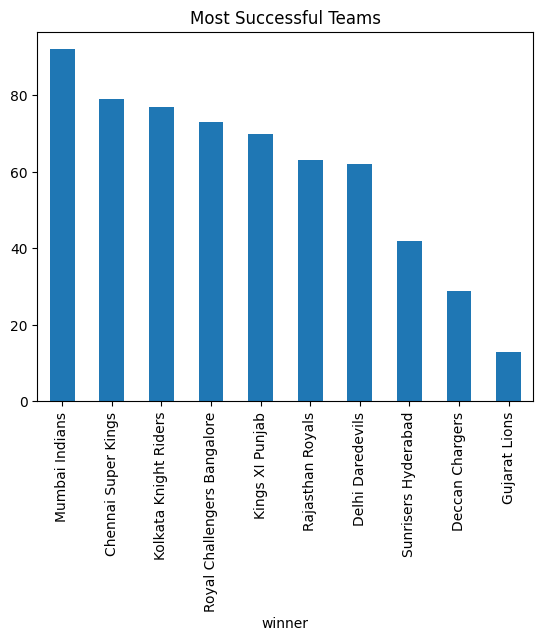

In [20]:
import matplotlib.pyplot as plt

matches["winner"].value_counts().head(10).plot(kind="bar")

plt.title("Most Successful Teams")
plt.show()

Season-wise Matches

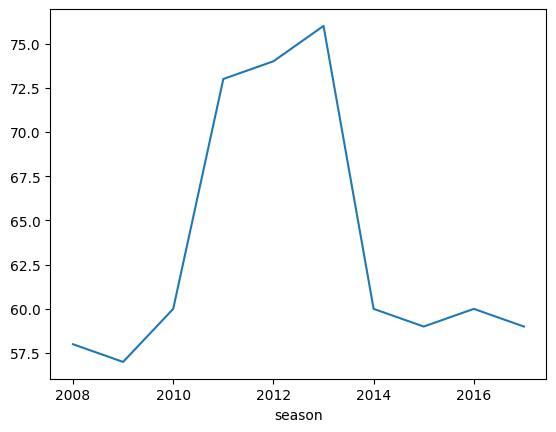

In [21]:
matches["season"].value_counts().sort_index().plot()

plt.show()

Runs Distribution

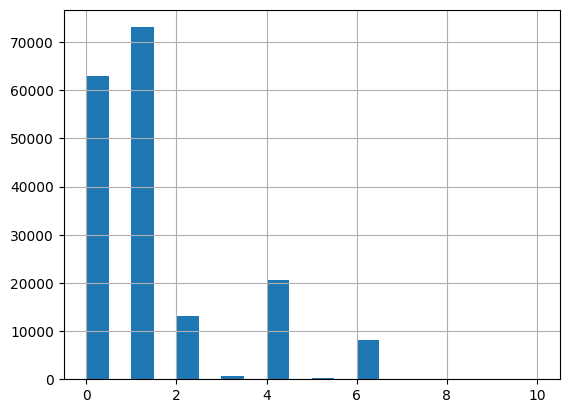

In [22]:
deliveries["total_runs"].hist(bins=20)

plt.show()

Seaborn Visualization
Heatmap

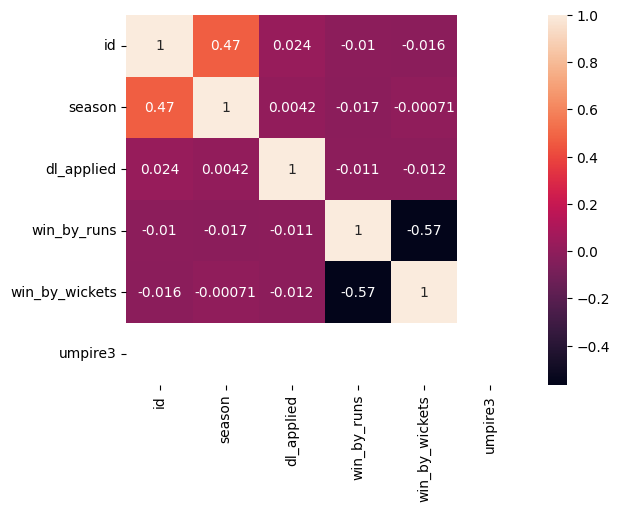

In [23]:
import seaborn as sns

corr = matches.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True)

plt.show()

Toss Decision Analysis

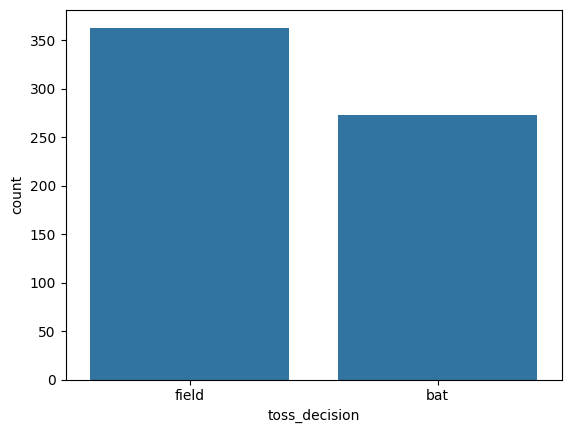

In [24]:
sns.countplot(
    data=matches,
    x="toss_decision"
)

plt.show()

Venue Analysis

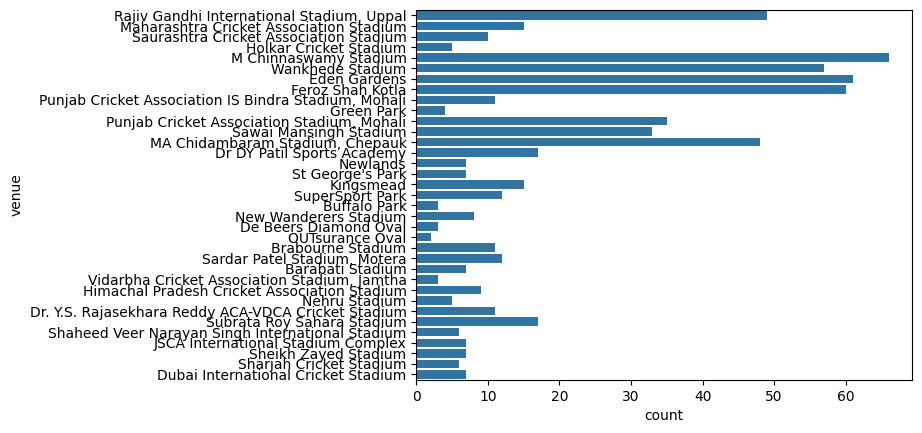

In [25]:
sns.countplot(
    y="venue",
    data=matches
)

plt.show()

SQL

In [5]:
import pandas as pd
import sqlite3

# Load CSV file
matches = pd.read_csv("matches.csv")

# Connect to SQLite database
conn = sqlite3.connect("ipl.db")

# Save DataFrame to SQL table
matches.to_sql(
    "matches",
    conn,
    if_exists="replace",
    index=False
)

print("Data inserted successfully!")

Data inserted successfully!


Advanced Pandas
GroupBy

In [2]:
import pandas as pd

deliveries = pd.read_csv("deliveries.csv")

print(deliveries.head())
player_runs = deliveries.groupby(
    "batsman"
)["total_runs"].sum()

print(
    player_runs.sort_values(
        ascending=False
    ).head(10)
)

   match_id  inning         batting_team                 bowling_team  over  \
0         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
1         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
2         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
3         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
4         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   

   ball    batsman non_striker    bowler  is_super_over  ...  bye_runs  \
0     1  DA Warner    S Dhawan  TS Mills              0  ...         0   
1     2  DA Warner    S Dhawan  TS Mills              0  ...         0   
2     3  DA Warner    S Dhawan  TS Mills              0  ...         0   
3     4  DA Warner    S Dhawan  TS Mills              0  ...         0   
4     5  DA Warner    S Dhawan  TS Mills              0  ...         0   

   legbye_runs  noball_runs  penalty_runs  batsman_runs  extra_runs  \
0        

Merge

In [4]:
import pandas as pd

matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")
ipl = pd.merge(
    deliveries,
    matches,
    left_on="match_id",
    right_on="id"
)

Pivot Table

In [5]:
pd.pivot_table(
    matches,
    values="id",
    index="season",
    columns="winner",
    aggfunc="count"
)

winner,Chennai Super Kings,Deccan Chargers,Delhi Daredevils,Gujarat Lions,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Mumbai Indians,Pune Warriors,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
season,,,,,,,,,,,,,,
2008,9.0,2.0,7.0,NaN,10.0,NaN,6.0,7.0,NaN,13.0,NaN,NaN,4.0,NaN
2009,8.0,9.0,10.0,NaN,7.0,NaN,3.0,5.0,NaN,6.0,NaN,NaN,9.0,NaN
2010,9.0,8.0,7.0,NaN,4.0,NaN,7.0,11.0,NaN,6.0,NaN,NaN,8.0,NaN
2011,11.0,6.0,4.0,NaN,7.0,6.0,8.0,10.0,4.0,6.0,NaN,NaN,10.0,NaN
2012,10.0,4.0,11.0,NaN,8.0,NaN,12.0,10.0,4.0,7.0,NaN,NaN,8.0,NaN
2013,12.0,NaN,3.0,NaN,8.0,NaN,6.0,13.0,4.0,11.0,NaN,NaN,9.0,10.0
2014,10.0,NaN,2.0,NaN,12.0,NaN,11.0,7.0,NaN,7.0,NaN,NaN,5.0,6.0
2015,10.0,NaN,5.0,NaN,3.0,NaN,7.0,10.0,NaN,7.0,NaN,NaN,8.0,7.0
2016,NaN,NaN,7.0,9.0,4.0,NaN,8.0,7.0,NaN,NaN,NaN,5.0,9.0,11.0


Feature Engineering
Strike Rate

In [6]:
balls = deliveries.groupby(
    "batsman"
).size()

runs = deliveries.groupby(
    "batsman"
)["total_runs"].sum()

strike_rate = (runs/balls)*100

Boundary Percentage

In [7]:
deliveries["boundary"] = (
    deliveries["total_runs"] >= 4
).astype(int)

Match Won After Winning Toss

In [8]:
matches["toss_match_win"] = (
    matches["toss_winner"] ==
    matches["winner"]
).astype(int)